In [38]:
import sys
import importlib
sys.path.append('../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(plot)

<module 'utilities.plot' from 'd:\\Lyumkis_Lab\\potts_model_test\\ms1\\..\\utilities\\plot.py'>

In [39]:
IN_seq_path = 'IN/data/in.reduce4.seq'
PR_seq_path = 'PR/data/pr.exper.reduce4.seq'    
RT_seq_path = 'RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq('IN/data/in.reduce4.seq')
PR_all_seq = functions.read_seq('PR/data/pr.exper.reduce4.seq')
RT_all_seq = functions.read_seq('RT/data/rt.reduce4.seq')

IN_consensus = 'IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = 'PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = 'RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('RT/data/rt.fullseq')

In [40]:
IN_double_mutation = "C140D-D148B"
pair1, pair2 = functions.split_pairs(IN_double_mutation)
wt1,pos1,mt1 = functions.split_pair(pair1)
wt2,pos2,mt2 = functions.split_pair(pair2)
IN_seq_w_mutation = [seq for seq in IN_all_seq if seq[pos1-1] == mt1 and seq[pos2-1] == mt2]
print(len(IN_seq_w_mutation))

221


In [41]:
p_SH_all = [functions.calculate_double_mutant_probablity(seq, 'C140D', 'D148B', IN_J, 1, 263) for seq in IN_seq_w_mutation]
lowest_prob_indices = sorted(range(len(p_SH_all)), key=p_SH_all.__getitem__)[:10]
highest_prob_indices = sorted(range(len(p_SH_all)), key=p_SH_all.__getitem__, reverse=True)[:10]

print("10 lowest probability indices:", lowest_prob_indices)
print("10 highest probability indices:", highest_prob_indices)


10 lowest probability indices: [47, 4, 25, 19, 44, 216, 203, 219, 43, 123]
10 highest probability indices: [172, 193, 55, 92, 210, 70, 0, 88, 190, 74]


In [42]:
min_position = 1
max_position = 263

print("Lowest probability indices and values:", [(i, p_SH_all[i]) for i in lowest_prob_indices])
print("Highest probability indices and values:", [(i, p_SH_all[i]) for i in highest_prob_indices])

Lowest probability indices and values: [(47, 0.0078008011428158715), (4, 0.02839939979021636), (25, 0.036290730736233984), (19, 0.05293694379698973), (44, 0.06180607417285105), (216, 0.06347475829697267), (203, 0.0804061252499757), (219, 0.09282441645037905), (43, 0.09960083643534463), (123, 0.10737489097461572)]
Highest probability indices and values: [(172, 0.992017937035009), (193, 0.9916040633740585), (55, 0.9907137456756973), (92, 0.9865014180602755), (210, 0.9859601692034983), (70, 0.9767481658536422), (0, 0.9730515346060088), (88, 0.972901931621783), (190, 0.9721215355148497), (74, 0.966167805132511)]


In [43]:
vectors_top10 = [functions.vectorize_seq_residue_energy(IN_seq_w_mutation[i], IN_J, min_position, max_position) for i in highest_prob_indices]
vectors_bottom10 = [functions.vectorize_seq_residue_energy(IN_seq_w_mutation[i], IN_J, min_position, max_position) for i in lowest_prob_indices]
print(sum(vectors_top10[0])/2)
print(sum(vectors_bottom10[0])/2)

with open('top_bottom_vectors.txt', 'w') as f:
    f.write("TOP_VECTORS\n")
    for v in vectors_top10:
        f.write(repr([float(x) for x in v]) + "\n")

    f.write("\nBOTTOM_VECTORS\n")
    for v in vectors_bottom10:
        f.write(repr([float(x) for x in v]) + "\n")

print("Wrote top_bottom_vectors.txt")

-1553.3951822695085
-1530.8304554369856
Wrote top_bottom_vectors.txt


In [44]:
# # verify vectorization on consensus sequence
# consensus_E = functions.calculate_e(IN_consensus_seq, IN_J, min_position, max_position)
# print(consensus_E)

# consensus_residue_E_vector = functions.vectorize_seq_residue_energy(IN_consensus_seq, IN_J, min_position, max_position)
# print(sum(consensus_residue_E_vector)/2)


In [45]:
# #verify E values for top and bottom sequences
# E_top10 = [functions.calculate_e(IN_seq_w_mutation[i], IN_J, min_position, max_position) for i in highest_prob_indices]
# E_bottom10 = [functions.calculate_e(IN_seq_w_mutation[i], IN_J, min_position, max_position) for i in lowest_prob_indices]
# print("E values for top 10 highest probability sequences:", E_top10)
# print("E values for top 10 lowest probability sequences:", E_bottom10)

Explained variance ratio: [0.16889991 0.10484721 0.09671648]


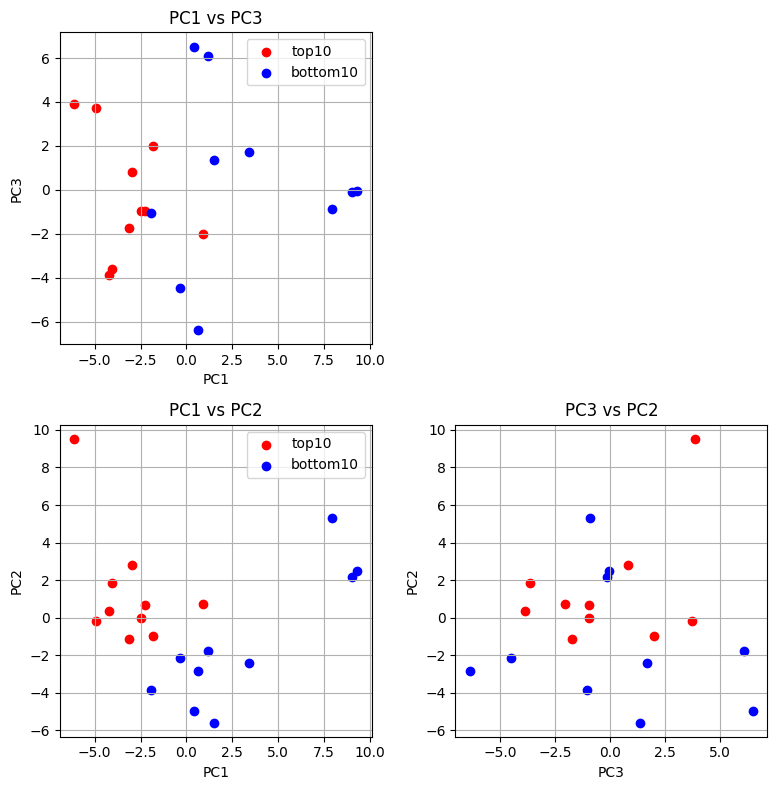

In [46]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_top = np.array(vectors_top10)
X_bot = np.array(vectors_bottom10)
X = np.vstack([X_top, X_bot])
labels = np.array([1]*len(X_top) + [0]*len(X_bot))

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)

fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(2, 2)

# top-left: PC1 vs PC3
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(X_pca[labels==1, 0], X_pca[labels==1, 2], c='r', label='top10')
ax1.scatter(X_pca[labels==0, 0], X_pca[labels==0, 2], c='b', label='bottom10')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC3'); ax1.set_title('PC1 vs PC3')
ax1.grid(True); ax1.legend(); ax1.set_box_aspect(1)

# bottom-left: PC1 vs PC2
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(X_pca[labels==1, 0], X_pca[labels==1, 1], c='r', label='top10')
ax2.scatter(X_pca[labels==0, 0], X_pca[labels==0, 1], c='b', label='bottom10')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.set_title('PC1 vs PC2')
ax2.grid(True); ax2.legend(); ax2.set_box_aspect(1)

# bottom-right: PC3 vs PC2
ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(X_pca[labels==1, 2], X_pca[labels==1, 1], c='r')
ax3.scatter(X_pca[labels==0, 2], X_pca[labels==0, 1], c='b')
ax3.set_xlabel('PC3'); ax3.set_ylabel('PC2'); ax3.set_title('PC3 vs PC2')
ax3.grid(True); ax3.set_box_aspect(1)

# top-right empty
ax_empty = fig.add_subplot(gs[0, 1])
ax_empty.axis('off')

plt.tight_layout()
plt.show()

# pc1 = pca.components_[0]
# print("PC1 eigenvector shape:", pc1.shape)
# print("PC1 eigenvector:", pc1)

Alphabet: ['A', 'B', 'C', 'D']
Sequence length (L): 263
One-hot depth (K): 4
Explained variance ratio (one-hot): [0.12877354 0.11035832 0.09436595]


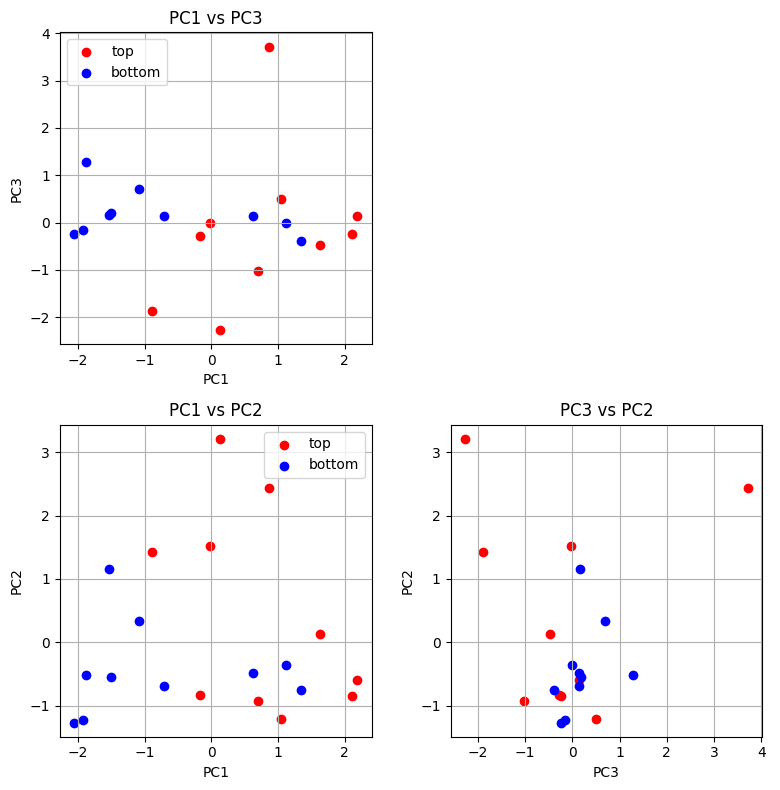

In [47]:
# One-hot encode sequences (per-residue) and run PCA on most/least probable sequences

# select sequences
top_seqs = [IN_seq_w_mutation[i] for i in highest_prob_indices]
bot_seqs = [IN_seq_w_mutation[i] for i in lowest_prob_indices]

# build alphabet from available sequences to ensure proper mapping
alphabet = sorted({ch for seq in IN_all_seq for ch in seq})
char2idx = {ch: idx for idx, ch in enumerate(alphabet)}
L = len(top_seqs[0])  # sequence length
K = len(alphabet)     # one-hot depth
print("Alphabet:", alphabet)
print("Sequence length (L):", L)
print("One-hot depth (K):", K)

def seq_one_hot_flat(seq):
    mat = np.zeros((L, K), dtype=np.float32)
    for j, ch in enumerate(seq):
        mat[j, char2idx[ch]] = 1.0
    return mat.ravel()

X_top_ohe = np.vstack([seq_one_hot_flat(s) for s in top_seqs])
X_bot_ohe = np.vstack([seq_one_hot_flat(s) for s in bot_seqs])
X_ohe = np.vstack([X_top_ohe, X_bot_ohe])
labels_ohe = np.array([1]*len(X_top_ohe) + [0]*len(X_bot_ohe))

pca_ohe = PCA(n_components=3)
Xo_pca = pca_ohe.fit_transform(X_ohe)
print("Explained variance ratio (one-hot):", pca_ohe.explained_variance_ratio_)

fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(2, 2)

# top-left: PC1 vs PC3
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(Xo_pca[labels_ohe==1, 0], Xo_pca[labels_ohe==1, 2], c='r', label='top')
ax1.scatter(Xo_pca[labels_ohe==0, 0], Xo_pca[labels_ohe==0, 2], c='b', label='bottom')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC3'); ax1.set_title('PC1 vs PC3')
ax1.grid(True); ax1.legend(); ax1.set_box_aspect(1)

# bottom-left: PC1 vs PC2
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(Xo_pca[labels_ohe==1, 0], Xo_pca[labels_ohe==1, 1], c='r', label='top')
ax2.scatter(Xo_pca[labels_ohe==0, 0], Xo_pca[labels_ohe==0, 1], c='b', label='bottom')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.set_title('PC1 vs PC2')
ax2.grid(True); ax2.legend(); ax2.set_box_aspect(1)

# bottom-right: PC3 vs PC2 (swapped axes)
ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(Xo_pca[labels_ohe==1, 2], Xo_pca[labels_ohe==1, 1], c='r')
ax3.scatter(Xo_pca[labels_ohe==0, 2], Xo_pca[labels_ohe==0, 1], c='b')
ax3.set_xlabel('PC3'); ax3.set_ylabel('PC2'); ax3.set_title('PC3 vs PC2')
ax3.grid(True); ax3.set_box_aspect(1)

# top-right left empty
ax_empty = fig.add_subplot(gs[0, 1])
ax_empty.axis('off')

plt.tight_layout()
plt.show()

# # select sequences
# top_seqs = [IN_seq_w_mutation[i] for i in highest_prob_indices]
# bot_seqs = [IN_seq_w_mutation[i] for i in lowest_prob_indices]

# # build alphabet from available sequences to ensure proper mapping
# alphabet = sorted({ch for seq in IN_all_seq for ch in seq})
# char2idx = {ch: idx for idx, ch in enumerate(alphabet)}
# L = len(top_seqs[0])  # sequence length
# K = len(alphabet)     # one-hot depth

# def seq_one_hot_flat(seq):
#     mat = np.zeros((L, K), dtype=np.float32)
#     for j, ch in enumerate(seq):
#         mat[j, char2idx[ch]] = 1.0
#     return mat.ravel()

# X_top_ohe = np.vstack([seq_one_hot_flat(s) for s in top_seqs])
# X_bot_ohe = np.vstack([seq_one_hot_flat(s) for s in bot_seqs])
# X_ohe = np.vstack([X_top_ohe, X_bot_ohe])
# labels_ohe = np.array([1]*len(X_top_ohe) + [0]*len(X_bot_ohe))

# pca_ohe = PCA(n_components=3)
# Xo_pca = pca_ohe.fit_transform(X_ohe)
# print("Explained variance ratio (one-hot):", pca_ohe.explained_variance_ratio_)

# plt.figure(figsize=(15,4))

# plt.subplot(1,3,1)
# plt.scatter(Xo_pca[labels_ohe==1,0], Xo_pca[labels_ohe==1,1], c='r', label='top')
# plt.scatter(Xo_pca[labels_ohe==0,0], Xo_pca[labels_ohe==0,1], c='b', label='bottom')
# plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PC1 vs PC2'); plt.legend(); plt.grid(True)

# plt.subplot(1,3,2)
# plt.scatter(Xo_pca[labels_ohe==1,0], Xo_pca[labels_ohe==1,2], c='r')
# plt.scatter(Xo_pca[labels_ohe==0,0], Xo_pca[labels_ohe==0,2], c='b')
# plt.xlabel('PC1'); plt.ylabel('PC3'); plt.title('PC1 vs PC3'); plt.grid(True)

# plt.subplot(1,3,3)
# plt.scatter(Xo_pca[labels_ohe==1,1], Xo_pca[labels_ohe==1,2], c='r')
# plt.scatter(Xo_pca[labels_ohe==0,1], Xo_pca[labels_ohe==0,2], c='b')
# plt.xlabel('PC2'); plt.ylabel('PC3'); plt.title('PC2 vs PC3'); plt.grid(True)

# plt.tight_layout()
# plt.show()

In [48]:
# One-hot encode top/bottom sequences and save to file
X_top_ohe_new = np.vstack([seq_one_hot_flat(s) for s in top_seqs])
X_bottom_ohe_new = np.vstack([seq_one_hot_flat(s) for s in bot_seqs])

with open('top_bottom_onehot.txt', 'w') as f:
    f.write("TOP_ONEHOT\n")
    for row in X_top_ohe_new:
        f.write(repr(row.astype(int).tolist()) + "\n")

    f.write("\nBOTTOM_ONEHOT\n")
    for row in X_bottom_ohe_new:
        f.write(repr(row.astype(int).tolist()) + "\n")

print("Wrote top_bottom_onehot.txt")
print("Top one-hot shape:", X_top_ohe_new.shape)
print("Bottom one-hot shape:", X_bottom_ohe_new.shape)

Wrote top_bottom_onehot.txt
Top one-hot shape: (10, 1052)
Bottom one-hot shape: (10, 1052)


X_trans.shape: (526, 10)
Explained variance ratio: [0.65418825 0.07536144]


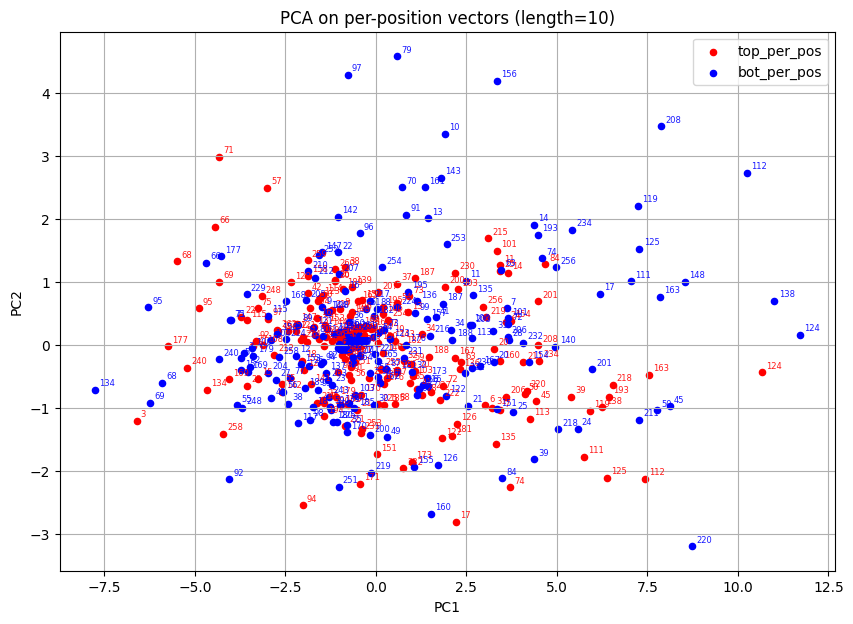

In [49]:
# Build per-position vectors of length 10 for top and bottom groups, then run PCA
data_top = X_top.T              # shape: (max_position, 10)
data_bot = X_bot.T              # shape: (max_position, 10)

X_trans = np.vstack([data_top, data_bot])   # shape: (max_position*2, 10)
labels_trans = np.array([1]*max_position + [0]*max_position)

pca2 = PCA(n_components=2)
X_trans_pca = pca2.fit_transform(X_trans)

print("X_trans.shape:", X_trans.shape)
print("Explained variance ratio:", pca2.explained_variance_ratio_)

plt.figure(figsize=(10,7))
plt.scatter(X_trans_pca[labels_trans==1,0], X_trans_pca[labels_trans==1,1], c='r', s=20, label='top_per_pos')
plt.scatter(X_trans_pca[labels_trans==0,0], X_trans_pca[labels_trans==0,1], c='b', s=20, label='bot_per_pos')

# annotate each point with its position index (1-based, using min_position)
for i, (x,y) in enumerate(X_trans_pca):
    pos = (i % max_position) + min_position
    col = 'r' if labels_trans[i]==1 else 'b'
    plt.annotate(str(pos), xy=(x,y), xytext=(3,3), textcoords='offset points',
                 fontsize=6, color=col, alpha=0.9)

plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(); plt.title('PCA on per-position vectors (length=10)'); plt.grid(True)
plt.show()